In [62]:
import re
import requests
import string
import numpy as np
import matplotlib.pyplot as plt

In [63]:
book = requests.get("https://www.gutenberg.org/files/35/35-0.txt").text
print(type(book))
print(len(book))

<class 'str'>
182973


In [64]:
# character strings to replace with spaces
strings2replace = ['\r\n\r\nâ\x80\x9c',
                   'â\x80\x9c',
                   'â\x80\x9d',
                   '\r\n',
                   'â\x80\x94',
                   'â\x80\x99',
                   'â\x80\x98','_', ]

'â\x80\x9c'.encode("latin1").decode("utf-8")

'“'

In [65]:
# here we are cleaning the text, but normally this is done by the tokenizer

for str2match in strings2replace:
    book = re.sub(str2match, ' ', book) # using regex to replace all occurrences of the string with a space

# remove non-ASCII characters
book = re.sub(r'[^\x00-\x7F]+', ' ', book)

# remove numbers
book = re.sub(r'\d+', ' ', book)

# make everything lowercase
book = book.lower()

print(book[:1000])

*** start of the project gutenberg ebook   ***     the time machine  an invention  by h. g. wells   contents   i introduction  ii the machine  iii the time traveller returns  iv time travelling  v in the golden age  vi the sunset of mankind  vii a sudden shock  viii explanation  ix the morlocks  x when night came  xi the palace of green porcelain  xii in the darkness  xiii the trap of the white sphinx  xiv the further vision  xv the time traveller s return  xvi after the story  epilogue      i.  introduction   the time traveller (for so it will be convenient to speak of him) was expounding a recondite matter to us. his pale grey eyes shone and twinkled, and his usually pale face was flushed and animated. the fire burnt brightly, and the soft radiance of the incandescent lights in the lilies of silver caught the bubbles that flashed and passed in our glasses. our chairs, being his patents, embraced and caressed us rather than submitted to be sat upon, and there was that luxurious after-

In [66]:
# parse text into words
print(string.punctuation)

# regex pattern to split by punctuation and whitespace, \s matches any whitespace character, + means one or more occurrences
regex_pattern_split = rf'[{string.punctuation}\s]+' 

words = re.split(regex_pattern_split, book)

# strip() removes leading and trailing whitespace from each word, and we also filter out empty strings
words = [item.strip() for item in words if item.strip() != ''] # remove empty strings and strip whitespace

# remove single character words, just for convenience, but this is not necessary for tokenization
words = [word for word in words if len(word) > 1]

print(words[:100])

!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~
['start', 'of', 'the', 'project', 'gutenberg', 'ebook', 'the', 'time', 'machine', 'an', 'invention', 'by', 'wells', 'contents', 'introduction', 'ii', 'the', 'machine', 'iii', 'the', 'time', 'traveller', 'returns', 'iv', 'time', 'travelling', 'in', 'the', 'golden', 'age', 'vi', 'the', 'sunset', 'of', 'mankind', 'vii', 'sudden', 'shock', 'viii', 'explanation', 'ix', 'the', 'morlocks', 'when', 'night', 'came', 'xi', 'the', 'palace', 'of', 'green', 'porcelain', 'xii', 'in', 'the', 'darkness', 'xiii', 'the', 'trap', 'of', 'the', 'white', 'sphinx', 'xiv', 'the', 'further', 'vision', 'xv', 'the', 'time', 'traveller', 'return', 'xvi', 'after', 'the', 'story', 'epilogue', 'introduction', 'the', 'time', 'traveller', 'for', 'so', 'it', 'will', 'be', 'convenient', 'to', 'speak', 'of', 'him', 'was', 'expounding', 'recondite', 'matter', 'to', 'us', 'his', 'pale', 'grey']


In [67]:
# create a vocabulary of unique words
vocab = set(words)

n_words = len(words)
n_lex = len(vocab)

print(f"Number of words: {n_words}")
print(f"Vocabulary size (tokens): {n_lex}") # it could be higher if we hand't removed single character words for example.

Number of words: 30698
Vocabulary size (tokens): 4589


In [68]:
# create token dictionaries and encode/decoder functions
word2idx = {word: idx for idx, word in enumerate(vocab)}
idx2word = {idx: word for word, idx in word2idx.items()}

def encoder(words, encode_dict):
    return [encode_dict[word] for word in words]

def decoder(indices, decode_dict):
    return " ".join([decode_dict[idx] for idx in indices])

# test the encoder and decoder functions
print(encoder(["the", "time", "machine"], word2idx))
print(decoder([1, 3, 10], idx2word))

[3415, 1364, 1057]
candle topic mortal


In [69]:
# test encode and decode random words
random_int = np.random.randint(0, n_lex, size=5)
print("Word indices:", random_int)
random_words = [idx2word[i] for i in random_int]
print("Random words:", random_words)
encoded_random_words = encoder(random_words, word2idx)
print("Token indices:", encoded_random_words)
decoded_random_words = decoder(encoded_random_words, idx2word)
print("Decoded random words:", decoded_random_words)

Word indices: [3734  337  227 3215 2178]
Random words: ['elusive', 'restore', 'overhead', 'beaten', 'lay']
Token indices: [3734, 337, 227, 3215, 2178]
Decoded random words: elusive restore overhead beaten lay


In [70]:
# random tokens
random_tokens = np.random.randint(0, n_lex, size=10)

# test with random tokens
print("Random tokens:", random_tokens)
print("Decoded random tokens:", decoder(random_tokens, idx2word))


Random tokens: [4157 3378  222 2951 2584 2657 1699 4269  537  533]
Decoded random tokens: biological slam threadbare first decadence tampering shadow hurry wing smiles


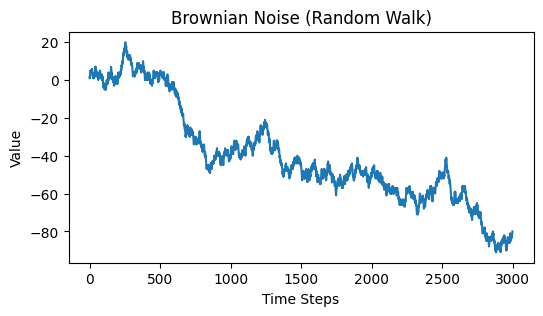

In [71]:
# brownian noise
brownian_noise = np.cumsum(np.random.choice([-1, 1], size=3000)) # cumulative sum of random values to create a random walk

plt.figure(figsize=(6, 3))
plt.plot(brownian_noise)
plt.title("Brownian Noise (Random Walk)")
plt.xlabel("Time Steps")
plt.ylabel("Value")
plt.show()

In [72]:
# brownian random tokens
brownian_random_tokens = brownian_noise + np.random.choice(n_lex, 1) # add a random offset to the brownian noise to create random tokens that fluctuate around a random value
print("Brownian random tokens:", brownian_random_tokens)

print(f"Brownian random tokens decoded: {decoder(brownian_random_tokens.astype(int), idx2word)}")

Brownian random tokens: [2646 2647 2646 ... 2563 2564 2565]
Brownian random tokens decoded: begrimed conveying begrimed conveying cadger gesture whirl gesture whirl gesture cadger gesture whirl gesture whirl gesture whirl walking whirl gesture cadger gesture cadger conveying begrimed conveying cadger conveying begrimed conveying begrimed conveying begrimed conveying cadger conveying cadger gesture whirl walking greyish walking greyish walking whirl walking whirl gesture cadger gesture cadger gesture cadger conveying cadger gesture cadger conveying begrimed conveying begrimed trembled begrimed conveying cadger conveying cadger gesture cadger conveying cadger gesture cadger gesture whirl gesture cadger conveying begrimed conveying cadger conveying cadger conveying cadger conveying begrimed trembled begrimed trembled begrimed conveying begrimed trembled eyeballs differences eyeballs differences wash believe wash believe wash believe wash believe judge believe wash differences wash believe

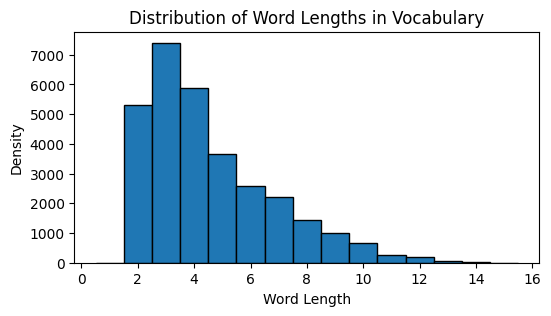

In [73]:
# check the length of each word in the vocabulary
word_lengths = np.array([len(word) for word in words])

# show distribution of word lengths
plt.figure(figsize=(6, 3))
plt.hist(word_lengths, bins=np.arange(1, max(word_lengths)+1) - 0.5, edgecolor="k")
plt.title("Distribution of Word Lengths in Vocabulary")
plt.xlabel("Word Length")
plt.ylabel("Density")
plt.show()

In [74]:
# encode a sentence
sentence = "The space aliens came to Earth to steal our water and enslave humanity."

# preprocess the sentence (remove punctuation and lowercase)
sentence = sentence.lower()
sentence = "".join([c for c in sentence if c.isalnum() or c.isspace()])
sentence_words = sentence.split()
print(sentence_words)

# tokenize the sentence
encoded_sentence = encoder(sentence_words, word2idx) # fails since aliens is not in the vocabulary, so we need to add it first
print("Encoded sentence:", encoded_sentence) 

['the', 'space', 'aliens', 'came', 'to', 'earth', 'to', 'steal', 'our', 'water', 'and', 'enslave', 'humanity']


KeyError: 'aliens'

In [83]:
# modify encoder to handle out-of-vocabulary words by assigning them a special token index (e.g., len(vocab) for <UNK>)

def encoder(words, encode_dict, decode_dict):
    # we can assign a special index for out-of-vocabulary words, for example, len(encode_dict) which would be the next index after the last word in the vocabulary
    unk_index = len(encode_dict)
    # update the encode_dict to include the <UNK> token
    encode_dict["<UNK>"] = unk_index
    # update the decode_dict to include the <UNK> token
    decode_dict[unk_index] = "<UNK>"

    return [encode_dict.get(word, unk_index) for word in words]

encoded_sentence = encoder(sentence_words, word2idx, idx2word)
print("Encoded sentence with OOV handling:", encoded_sentence)
print("Decoded sentence with OOV handling:", decoder(encoded_sentence, idx2word))

Encoded sentence with OOV handling: [3415, 4423, 4590, 704, 3283, 705, 3283, 4590, 3311, 1254, 2064, 4590, 1576]
Decoded sentence with OOV handling: the space <UNK> came to earth to <UNK> our water and <UNK> humanity
